# DeepEval LLM-as-Judge Analysis
**Порівняння GPT-4o vs Claude Sonnet 4.6**  
Judge: GPT-4.1 (незалежний крос-провайдерний суддя)

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

REPORTS = Path('reports')

openai_data  = json.loads((REPORTS / 'deepeval_results_openai.json').read_text())
claude_data  = json.loads((REPORTS / 'deepeval_results_anthropic.json').read_text())

df_openai = pd.DataFrame(openai_data)
df_claude = pd.DataFrame(claude_data)
df_openai['model'] = 'GPT-4o'
df_claude['model'] = 'Claude Sonnet 4.6'
df = pd.concat([df_openai, df_claude], ignore_index=True)

print(f'OpenAI:  {len(df_openai)} сценаріїв')
print(f'Claude:  {len(df_claude)} сценаріїв')
df.head(3)

OpenAI:  44 сценаріїв
Claude:  44 сценаріїв


,id,metric,score,passed,reason,provider,threshold,model
0,fq_first_message_general_fields,followup_quality,1.0000,True,The Actual Output asks only about the missing ...,openai,0.7,GPT-4o
1,fq_box_details_block,followup_quality,0.9038,True,The response does not repeat the already provi...,openai,0.7,GPT-4o
2,fq_rulebook_details,followup_quality,0.1712,False,The response does not ask for any of the missi...,openai,0.7,GPT-4o


## 1. Загальні показники

In [2]:
summary = df.groupby('model').agg(
    total=('score', 'count'),
    passed=('passed', 'sum'),
    avg_score=('score', 'mean'),
    min_score=('score', 'min'),
    max_score=('score', 'max'),
    std_score=('score', 'std'),
).round(3)
summary['pass_rate'] = (summary['passed'] / summary['total'] * 100).round(1).astype(str) + '%'
print(summary.to_string())

                   total  passed  avg_score  min_score  max_score  std_score pass_rate
model                                                                                 
Claude Sonnet 4.6     44      38      0.848      0.204        1.0      0.215     86.4%
GPT-4o                44      39      0.836      0.171        1.0      0.220     88.6%


## 2. Pass rate по метриках

In [3]:
METRIC_LABELS = {
    'followup_quality':  'Follow-up Quality',
    'guardrail_quality': 'Guardrail Quality',
    'no_hallucination':  'No Hallucination',
    'convo_coherence':   'Convo Coherence',
}

metric_summary = df.groupby(['model', 'metric']).agg(
    passed=('passed', 'sum'),
    total=('score', 'count'),
    avg=('score', 'mean')
).reset_index()
metric_summary['pass_rate'] = metric_summary['passed'] / metric_summary['total'] * 100
metric_summary['label'] = metric_summary['metric'].map(METRIC_LABELS)
print(metric_summary[['model','label','passed','total','pass_rate','avg']].to_string(index=False))

            model             label  passed  total  pass_rate      avg
Claude Sonnet 4.6   Convo Coherence       9     10  90.000000 0.756010
Claude Sonnet 4.6 Follow-up Quality      10     14  71.428571 0.789807
Claude Sonnet 4.6 Guardrail Quality       8      8 100.000000 0.991337
Claude Sonnet 4.6  No Hallucination      11     12  91.666667 0.896758
           GPT-4o   Convo Coherence       8     10  80.000000 0.739790
           GPT-4o Follow-up Quality      12     14  85.714286 0.778957
           GPT-4o Guardrail Quality       8      8 100.000000 0.966788
           GPT-4o  No Hallucination      11     12  91.666667 0.895658


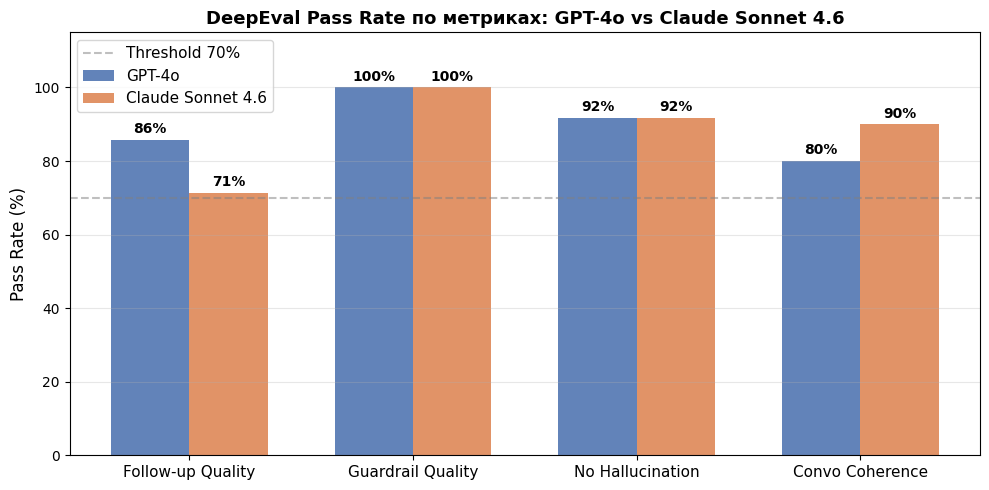

Збережено: deepeval_passrate_comparison.png


In [4]:
metrics = list(METRIC_LABELS.keys())
labels  = [METRIC_LABELS[m] for m in metrics]

openai_rates = []
claude_rates = []
for m in metrics:
    o = df[(df.model=='GPT-4o') & (df.metric==m)]
    c = df[(df.model=='Claude Sonnet 4.6') & (df.metric==m)]
    openai_rates.append(o['passed'].sum() / len(o) * 100 if len(o) else 0)
    claude_rates.append(c['passed'].sum() / len(c) * 100 if len(c) else 0)

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, openai_rates, w, label='GPT-4o',            color='#4C72B0', alpha=0.88)
bars2 = ax.bar(x + w/2, claude_rates, w, label='Claude Sonnet 4.6', color='#DD8452', alpha=0.88)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Pass Rate (%)', fontsize=12)
ax.set_title('DeepEval Pass Rate по метриках: GPT-4o vs Claude Sonnet 4.6', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 115)
ax.axhline(y=70, color='gray', linestyle='--', alpha=0.5, label='Threshold 70%')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'deepeval_passrate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Збережено: deepeval_passrate_comparison.png')

## 3. Середній score по метриках (boxplot)

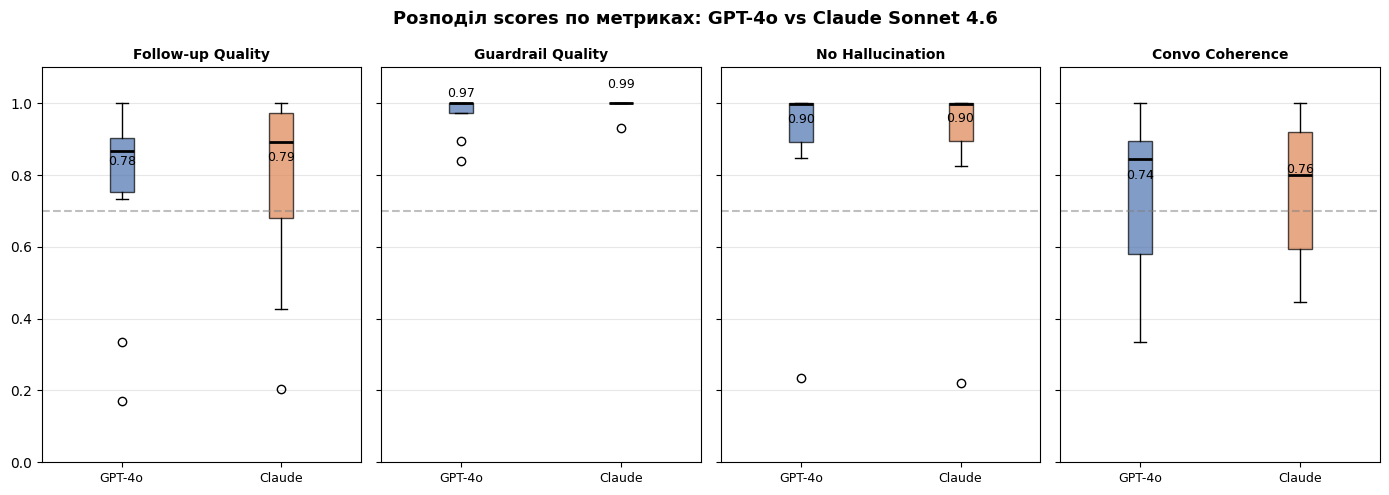

Збережено: deepeval_boxplot.png


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)
colors = {'GPT-4o': '#4C72B0', 'Claude Sonnet 4.6': '#DD8452'}

for ax, metric in zip(axes, metrics):
    data_o = df[(df.model=='GPT-4o') & (df.metric==metric)]['score'].values
    data_c = df[(df.model=='Claude Sonnet 4.6') & (df.metric==metric)]['score'].values
    bp = ax.boxplot([data_o, data_c], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#DD8452')
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(METRIC_LABELS[metric], fontsize=10, fontweight='bold')
    ax.set_xticklabels(['GPT-4o', 'Claude'], fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    # annotate mean
    for i, data in enumerate([data_o, data_c], 1):
        ax.text(i, np.mean(data) + 0.05, f'{np.mean(data):.2f}',
                ha='center', fontsize=9, color='black')

fig.suptitle('Розподіл scores по метриках: GPT-4o vs Claude Sonnet 4.6', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'deepeval_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Збережено: deepeval_boxplot.png')

## 4. Radar chart — профіль якості

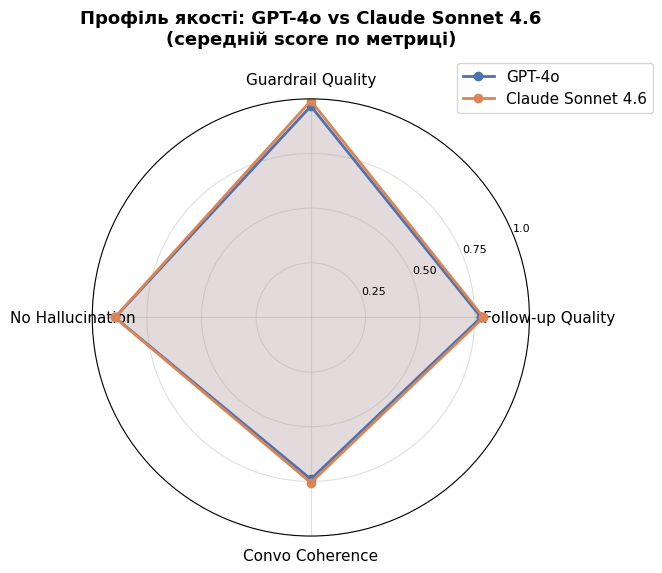

Збережено: deepeval_radar.png


In [6]:
avg_scores = {}
for model in ['GPT-4o', 'Claude Sonnet 4.6']:
    avg_scores[model] = [
        df[(df.model==model) & (df.metric==m)]['score'].mean()
        for m in metrics
    ]

N = len(metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for model, color in [('GPT-4o', '#4C72B0'), ('Claude Sonnet 4.6', '#DD8452')]:
    vals = avg_scores[model] + avg_scores[model][:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([METRIC_LABELS[m] for m in metrics], fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], fontsize=8)
ax.set_title('Профіль якості: GPT-4o vs Claude Sonnet 4.6\n(середній score по метриці)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(REPORTS / 'deepeval_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Збережено: deepeval_radar.png')

## 5. Сценарії де є розбіжність між моделями

In [7]:
pivot = df.pivot_table(index=['id', 'metric'], columns='model', values='score').reset_index()
pivot.columns.name = None
pivot['diff'] = pivot['Claude Sonnet 4.6'] - pivot['GPT-4o']
pivot['abs_diff'] = pivot['diff'].abs()

print('=== Топ-10 сценаріїв де Claude краще ===')
top_claude = pivot.nlargest(10, 'diff')[['id', 'metric', 'GPT-4o', 'Claude Sonnet 4.6', 'diff']]
print(top_claude.to_string(index=False))

print('\n=== Топ-5 сценаріїв де GPT-4o краще ===')
top_gpt = pivot.nsmallest(5, 'diff')[['id', 'metric', 'GPT-4o', 'Claude Sonnet 4.6', 'diff']]
print(top_gpt.to_string(index=False))

=== Топ-10 сценаріїв де Claude краще ===
                                       id            metric  GPT-4o  Claude Sonnet 4.6   diff
                      fq_rulebook_details  followup_quality  0.1712             1.0000 0.8288
           fq2_default_thickness_proposal  followup_quality  0.3341             0.9887 0.6546
                    cv_full_box_card_flow   convo_coherence  0.3341             0.5087 0.1746
            fq2_matte_lamination_proposal  followup_quality  0.7324             0.8961 0.1637
gr2_partial_off_topic_only_game_processed guardrail_quality  0.8403             1.0000 0.1597
         cv2_no_re_ask_after_confirmation   convo_coherence  0.4169             0.5743 0.1574
                 fq_progress_confirmation  followup_quality  0.8512             0.9928 0.1416
          fq2_cards_print_colors_followup  followup_quality  0.8829             1.0000 0.1171
               gr2_packaging_but_not_game guardrail_quality  0.8940             1.0000 0.1060
  cv2_expert_fills_

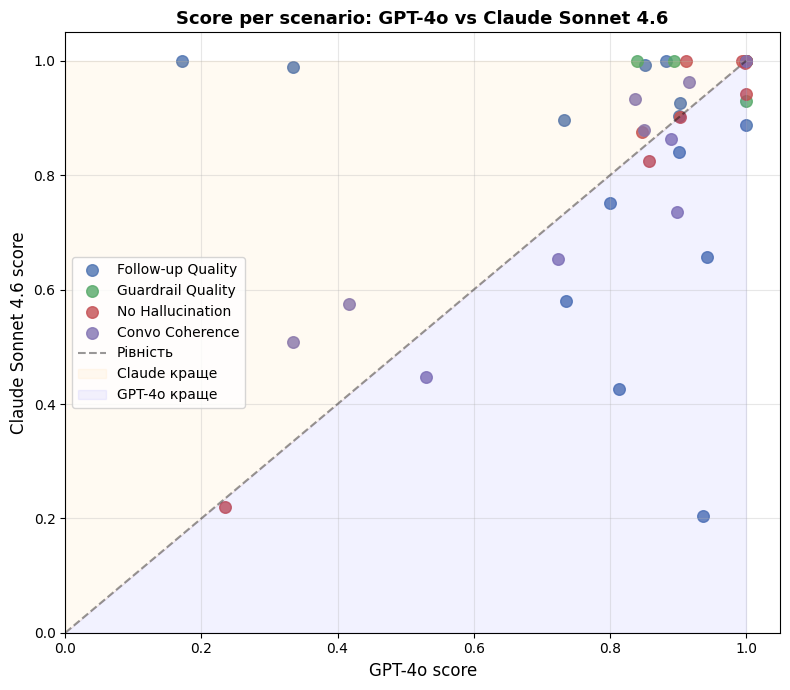

Збережено: deepeval_scatter.png


In [8]:
# Scatter plot: GPT-4o score vs Claude score per scenario
fig, ax = plt.subplots(figsize=(8, 7))

metric_colors = {
    'followup_quality':  '#4C72B0',
    'guardrail_quality': '#55A868',
    'no_hallucination':  '#C44E52',
    'convo_coherence':   '#8172B2',
}

for metric, color in metric_colors.items():
    sub = pivot[pivot['metric'] == metric]
    ax.scatter(sub['GPT-4o'], sub['Claude Sonnet 4.6'],
               c=color, label=METRIC_LABELS[metric], s=70, alpha=0.8)

# diagonal line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Рівність')
ax.fill_between([0, 1], [0, 1], [1, 1], alpha=0.05, color='orange', label='Claude краще')
ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.05, color='blue',   label='GPT-4o краще')

ax.set_xlabel('GPT-4o score', fontsize=12)
ax.set_ylabel('Claude Sonnet 4.6 score', fontsize=12)
ax.set_title('Score per scenario: GPT-4o vs Claude Sonnet 4.6', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'deepeval_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Збережено: deepeval_scatter.png')

## 6. Підсумкова таблиця для диплому

In [9]:
print('=' * 65)
print(f'{"Метрика":<25} {"GPT-4o":>12} {"Claude 4.6":>12} {"Δ":>8}')
print('=' * 65)

for metric in metrics:
    o_scores = df[(df.model=='GPT-4o') & (df.metric==metric)]
    c_scores = df[(df.model=='Claude Sonnet 4.6') & (df.metric==metric)]
    o_pass = f"{o_scores['passed'].sum()}/{len(o_scores)} ({o_scores['passed'].mean()*100:.0f}%)"
    c_pass = f"{c_scores['passed'].sum()}/{len(c_scores)} ({c_scores['passed'].mean()*100:.0f}%)"
    delta = c_scores['passed'].mean()*100 - o_scores['passed'].mean()*100
    sign = '+' if delta >= 0 else ''
    print(f'{METRIC_LABELS[metric]:<25} {o_pass:>12} {c_pass:>12} {sign}{delta:.0f}%')

print('=' * 65)
o_total = df[df.model=='GPT-4o']['passed'].mean()*100
c_total = df[df.model=='Claude Sonnet 4.6']['passed'].mean()*100
delta = c_total - o_total
sign = '+' if delta >= 0 else ''
print(f'{"ЗАГАЛОМ":<25} {o_total:.1f}%        {c_total:.1f}%        {sign}{delta:.1f}%')
print('=' * 65)

Метрика                         GPT-4o   Claude 4.6        Δ
Follow-up Quality          12/14 (86%)  10/14 (71%) -14%
Guardrail Quality           8/8 (100%)   8/8 (100%) +0%
No Hallucination           11/12 (92%)  11/12 (92%) +0%
Convo Coherence             8/10 (80%)   9/10 (90%) +10%
ЗАГАЛОМ                   88.6%        86.4%        -2.3%


## 7. Комбінована таблиця (Extraction + DeepEval)

In [ ]:
# Load extraction results
ext_openai = json.loads((REPORTS / 'results_openai.json').read_text()) \
    if (REPORTS / 'results_openai.json').exists() else None
ext_claude = json.loads((REPORTS / 'results_anthropic.json').read_text()) \
    if (REPORTS / 'results_anthropic.json').exists() else \
    json.loads((REPORTS / 'results.json').read_text())

def ext_stats(data):
    passed = sum(1 for x in data if x['passed'])
    total = len(data)
    all_fields = [f for x in data for f in x.get('field_results', [])]
    tp = sum(1 for f in all_fields if f['ok'])
    f1 = tp / len(all_fields) * 100 if all_fields else 0
    return passed, total, f1

if ext_openai:
    o_p, o_t, o_f1 = ext_stats(ext_openai)
    c_p, c_t, c_f1 = ext_stats(ext_claude)
    print('\n=== ЗВЕДЕНА ТАБЛИЦЯ ДЛЯ ДИПЛОМУ ===')
    print(f'{"":<30} {"GPT-4o":>15} {"Claude 4.6":>15}')
    print('-' * 60)
    print(f'{"Extraction pass rate":<30} {o_p/o_t*100:>14.1f}% {c_p/c_t*100:>14.1f}%')
    print(f'{"Extraction Field F1":<30} {o_f1:>14.1f}% {c_f1:>14.1f}%')
    print(f'{"DeepEval pass rate":<30} {o_total:>14.1f}% {c_total:>14.1f}%')
    for metric in metrics:
        o = df[(df.model=="GPT-4o") & (df.metric==metric)]['passed'].mean()*100
        c = df[(df.model=="Claude Sonnet 4.6") & (df.metric==metric)]['passed'].mean()*100
        print(f'  {METRIC_LABELS[metric]:<28} {o:>14.1f}% {c:>14.1f}%')
else:
    print('results_openai.json ще не готовий — дочекайся завершення extraction тестів')